<a href="https://colab.research.google.com/github/marcelcerri/Python_biocientistas_unesp/blob/main/Aula_4_Regress%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear

Apresentar a função array, np.random.normal e o linregress.

Inclinação (slope): 0.0200
Intercepto (intercept): 0.0071
R-quadrado: 0.9989


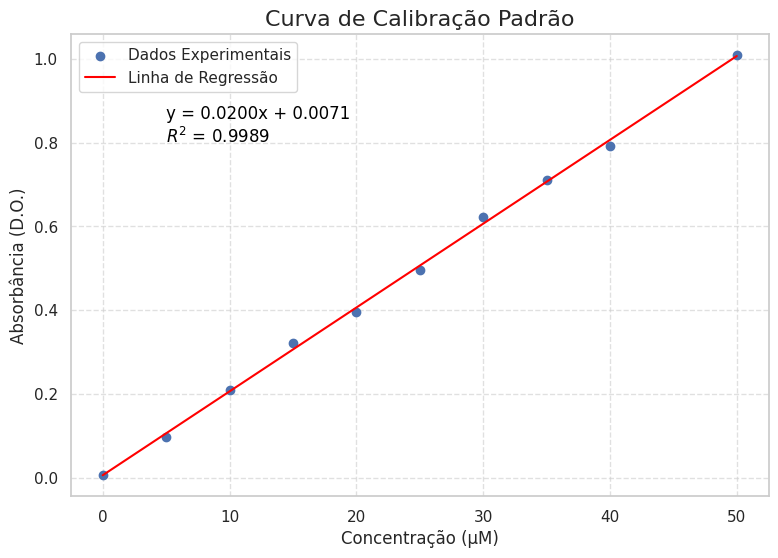

In [ ]:
# 1. Importar as bibliotecas necessárias
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress # A função de regressão linear!

# --- 2. PREPARAÇÃO DOS DADOS (SIMULADOS) ---
# Vamos simular os dados de uma curva de calibração.
# Estes seriam os pontos que você mediria em um espectrofotômetro.

# Eixo X: Concentrações conhecidas dos seus padrões (em µM)
concentracao = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 50])

# Eixo Y: Leituras de absorbância correspondentes.
# Vamos criar uma relação linear (y = 0.02 * x) e adicionar um "ruído"
# para simular a pequena variabilidade de um experimento real.
np.random.seed(42) # Para resultados reprodutíveis
absorbancia = 0.02 * concentracao + np.random.normal(0, 0.015, size=len(concentracao))


# --- 3. REALIZAR A REGRESSÃO LINEAR ---
# A função linregress da biblioteca SciPy faz todo o trabalho pesado!
# Ela retorna vários resultados importantes sobre a linha.
slope, intercept, r_value, p_value, std_err = linregress(concentracao, absorbancia)

print(f"Inclinação (slope): {slope:.4f}")
print(f"Intercepto (intercept): {intercept:.4f}")
# O R-quadrado nos diz quão bem a linha se ajusta aos dados (valor de 0 a 1)
print(f"R-quadrado: {r_value**2:.4f}")


# --- 4. VISUALIZAR OS DADOS E A LINHA DE REGRESSÃO ---

# Usamos a inclinação e o intercepto para calcular os pontos da linha de regressão
linha_regressao = slope * concentracao + intercept

# Criar o gráfico
plt.figure(figsize=(9, 6))

# a) Plotar os pontos de dados originais (gráfico de dispersão)
plt.scatter(concentracao, absorbancia, label='Dados Experimentais')

# b) Plotar a linha de regressão
plt.plot(concentracao, linha_regressao, color='red', label='Linha de Regressão')

# Adicionar a equação da linha e o R² ao gráfico para uma figura completa
plt.text(5, 0.8, f'y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r_value**2:.4f}', fontsize=12, color='black')

# Adicionar títulos e rótulos
plt.title('Curva de Calibração Padrão', fontsize=16)
plt.xlabel('Concentração (µM)')
plt.ylabel('Absorbância (D.O.)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Exibir o gráfico
plt.show()

Cx0 otimizado: 1.050567008529991
mi otimizado: 0.10932755385736757
R quadrado 0.9973473715007756


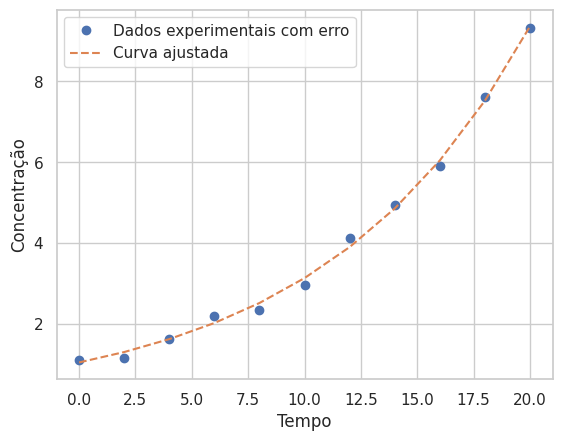

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Defina a semente para reprodutibilidade
np.random.seed(42)

def cresc_microbiano(t, Cx0, mi):
    return Cx0 * np.exp(mi * t)

# Dados experimentais originais
tempo_experimental = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
concentracao_experimental = np.array([1.0, 1.2, 1.5, 1.9, 2.4, 3.0, 3.8, 4.8, 6.0, 7.5, 9.4])

# Adicionando erro aleatório
erro_aleatorio = np.random.normal(0, 0.20, len(concentracao_experimental))
concentracao_experimental_com_erro = concentracao_experimental + erro_aleatorio

# Ajuste da curva
parametros_otimizados, matriz_covariancia = curve_fit(cresc_microbiano, tempo_experimental, concentracao_experimental_com_erro)
Cx0_otimizado, mi_otimizado = parametros_otimizados

print(f"Cx0 otimizado: {Cx0_otimizado}")
print(f"mi otimizado: {mi_otimizado}")

# Valores previstos pelo modelo
concentracao_prevista = cresc_microbiano(tempo_experimental, Cx0_otimizado, mi_otimizado)

# Cálculo do coeficiente de determinação
r_squared = r2_score(concentracao_experimental_com_erro, concentracao_prevista)
print(f"R quadrado {r_squared}")

# Gráfico
plt.plot(tempo_experimental, concentracao_experimental_com_erro, 'o', label='Dados experimentais com erro')
plt.plot(tempo_experimental, concentracao_prevista, '--', label='Curva ajustada')
plt.xlabel('Tempo')
plt.ylabel('Concentração')
plt.legend()
plt.show()

--- Resultados do Ajuste da Curva ---
Concentração Inicial (Cx0) estimada: 1.0506 g/L
Taxa de Crescimento (μ) estimada: 0.1093 h⁻¹
R-quadrado (R²): 0.9973


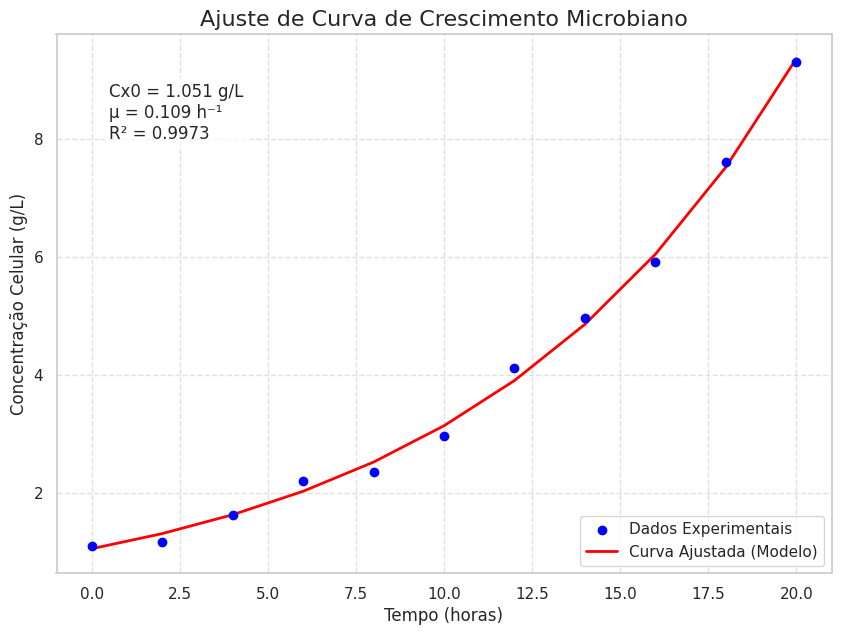

In [ ]:
# --- 1. IMPORTAÇÃO DAS BIBLIOTECAS ---
# Vamos precisar de ferramentas para matemática, otimização, gráficos e métricas.

import numpy as np
from scipy.optimize import curve_fit  # A estrela da aula: nossa ferramenta de ajuste de curvas
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score      # Para calcular o R-quadrado, uma medida de quão bom foi o ajuste

# --- 2. DEFINIÇÃO DO MODELO BIOLÓGICO (A NOSSA HIPÓTESE) ---
# Primeiro, definimos a equação matemática que acreditamos descrever nosso sistema.
# Para a fase exponencial de crescimento, o modelo é: Cx(t) = Cx0 * e^(μ*t)

def modelo_crescimento_exponencial(t, conc_inicial, taxa_crescimento):
    """
    Calcula a concentração celular (Cx) em um tempo (t).
    - t: tempo
    - conc_inicial: Concentração inicial de células (Cx0)
    - taxa_crescimento: Taxa específica de crescimento (μ)
    """
    return conc_inicial * np.exp(taxa_crescimento * t)

# --- 3. DADOS EXPERIMENTAIS (SIMULADOS) ---
# Estes são os dados que teríamos coletado em um experimento no laboratório.

# Pontos de tempo em que as amostras foram coletadas (horas)
tempo_exp = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

# Concentração de células medida em cada tempo (g/L)
conc_exp_real = np.array([1.0, 1.2, 1.5, 1.9, 2.4, 3.0, 3.8, 4.8, 6.0, 7.5, 9.4])

# Nenhum experimento é perfeito. Vamos adicionar um pequeno "ruído" para simular o erro experimental.
np.random.seed(42) # Garante que o "erro" seja o mesmo toda vez que rodamos o código
erro = np.random.normal(0, 0.20, len(conc_exp_real))
conc_exp_com_erro = conc_exp_real + erro

# --- 4. AJUSTE DA CURVA (ENCONTRANDO OS MELHORES PARÂMETROS) ---
# Aqui, pedimos ao SciPy para encontrar os valores de 'conc_inicial' e 'taxa_crescimento'
# que fazem a nossa função-modelo se ajustar o melhor possível aos dados experimentais.

params_otimizados, _ = curve_fit(modelo_crescimento_exponencial, tempo_exp, conc_exp_com_erro)

# Desempacotando os resultados encontrados
conc_inicial_otimizada, taxa_crescimento_otimizada = params_otimizados

# --- 5. AVALIAÇÃO DO AJUSTE ---
# Usamos os parâmetros otimizados para prever os valores segundo o nosso modelo.
conc_prevista_modelo = modelo_crescimento_exponencial(tempo_exp, conc_inicial_otimizada, taxa_crescimento_otimizada)

# Calculamos o R-quadrado para ver a qualidade do ajuste (0 a 1)
r_quadrado = r2_score(conc_exp_com_erro, conc_prevista_modelo)

# Imprimindo os resultados no console
print("--- Resultados do Ajuste da Curva ---")
print(f"Concentração Inicial (Cx0) estimada: {conc_inicial_otimizada:.4f} g/L")
print(f"Taxa de Crescimento (μ) estimada: {taxa_crescimento_otimizada:.4f} h⁻¹")
print(f"R-quadrado (R²): {r_quadrado:.4f}")

# --- 6. VISUALIZAÇÃO GRÁFICA ---
# Um bom gráfico é essencial para comunicar os resultados.

plt.figure(figsize=(10, 7))

# a) Plotar os dados experimentais como pontos
plt.scatter(tempo_exp, conc_exp_com_erro, label='Dados Experimentais', color='blue', zorder=5)

# b) Plotar a curva ajustada pelo modelo como uma linha
plt.plot(tempo_exp, conc_prevista_modelo, label='Curva Ajustada (Modelo)', color='red', linewidth=2)

# Adicionar títulos e rótulos claros com unidades
plt.title('Ajuste de Curva de Crescimento Microbiano', fontsize=16)
plt.xlabel('Tempo (horas)')
plt.ylabel('Concentração Celular (g/L)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar uma caixa de texto com os resultados diretamente no gráfico
texto_resultados = (
    f'Cx0 = {conc_inicial_otimizada:.3f} g/L\n'
    f'μ = {taxa_crescimento_otimizada:.3f} h⁻¹\n'
    f'R² = {r_quadrado:.4f}'
)
plt.text(0.5, 8.0, texto_resultados, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.7))

# Exibir o gráfico final
plt.show()

--- Resultados do Ajuste Polinomial ---
Coeficientes (a, b, c): [-0.0098954   0.47931006  2.517739  ]
Equação: y = -0.010x² + 0.479x + 2.518
R-quadrado (R²): 0.9680


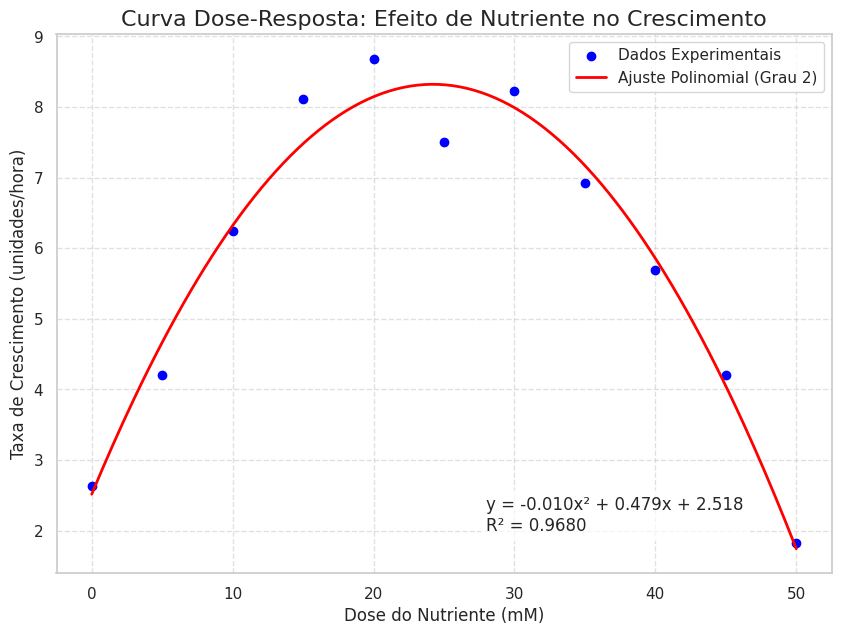

In [ ]:
# --- 1. IMPORTAÇÃO DAS BIBLIOTECAS ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score # Reutilizando para R²

# --- 2. DADOS EXPERIMENTAIS (SIMULADOS) ---
# Vamos simular o efeito da concentração de um nutriente na taxa de crescimento de uma cultura.
# Pouco nutriente = baixo crescimento.
# Nutriente demais = toxicidade, baixo crescimento.
# Existe uma concentração ótima no meio.

# Eixo X: Doses do nutriente testadas (em mM)
doses_nutriente = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])

# Eixo Y: Taxa de crescimento observada (unidades/hora)
# Simulamos uma parábola (y = -ax² + bx + c) e adicionamos ruído.
np.random.seed(0)
taxa_crescimento_exp = -0.01 * (doses_nutriente - 25)**2 + 8 + np.random.normal(0, 0.5, len(doses_nutriente))


# --- 3. AJUSTE DO POLINÔMIO COM `numpy.polyfit` ---
# Esta função encontra os coeficientes do polinômio que melhor se ajusta aos dados.
# O último argumento (2) é o GRAU do polinômio. 2 = parábola (ax² + bx + c).
coeficientes = np.polyfit(doses_nutriente, taxa_crescimento_exp, 2)

# np.poly1d é uma função auxiliar que transforma os coeficientes em um modelo matemático usável.
modelo_polinomial = np.poly1d(coeficientes)

print("--- Resultados do Ajuste Polinomial ---")
print(f"Coeficientes (a, b, c): {coeficientes}")
print(f"Equação: y = {coeficientes[0]:.3f}x² + {coeficientes[1]:.3f}x + {coeficientes[2]:.3f}")


# --- 4. AVALIAÇÃO DO AJUSTE ---
# Geramos pontos no eixo X para criar uma curva suave para o gráfico
doses_curva_suave = np.linspace(0, 50, 200)
crescimento_previsto_curva = modelo_polinomial(doses_curva_suave)

# Calculamos o R² comparando os dados experimentais com os valores previstos pelo modelo
r_quadrado = r2_score(taxa_crescimento_exp, modelo_polinomial(doses_nutriente))
print(f"R-quadrado (R²): {r_quadrado:.4f}")

# --- 5. VISUALIZAÇÃO GRÁFICA ---
plt.figure(figsize=(10, 7))

# a) Plotar os dados experimentais
plt.scatter(doses_nutriente, taxa_crescimento_exp, label='Dados Experimentais', color='blue')

# b) Plotar a curva polinomial ajustada
plt.plot(doses_curva_suave, crescimento_previsto_curva, label='Ajuste Polinomial (Grau 2)', color='red', linewidth=2)

# Adicionar títulos e rótulos
plt.title('Curva Dose-Resposta: Efeito de Nutriente no Crescimento', fontsize=16)
plt.xlabel('Dose do Nutriente (mM)')
plt.ylabel('Taxa de Crescimento (unidades/hora)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar uma caixa de texto com a equação e o R²
texto_resultados = (
    f'y = {coeficientes[0]:.3f}x² + {coeficientes[1]:.3f}x + {coeficientes[2]:.3f}\n'
    f'R² = {r_quadrado:.4f}'
)
plt.text(28, 2, texto_resultados, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.7))

# Exibir o gráfico final
plt.show()

--- Parâmetros Cinéticos Estimados ---
Velocidade Máxima (Vmax): 80.05 μmol/min
Constante de Michaelis (Km): 3.54 mM


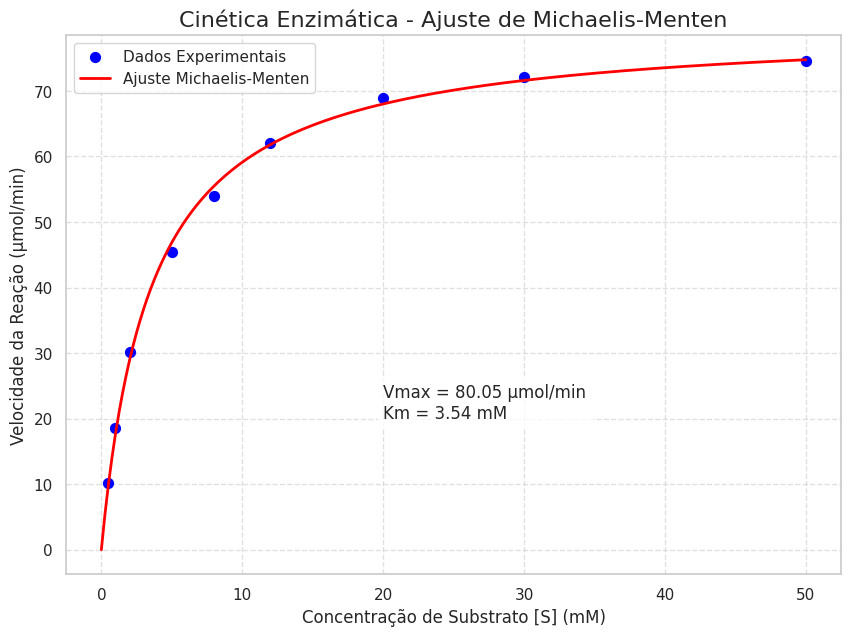

In [ ]:
# --- 1. IMPORTAÇÃO DAS BIBLIOTECAS ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- DADOS FORNECIDOS NO EXERCÍCIO ---
concentracao_substrato = np.array([0.5, 1.0, 2.0, 5.0, 8.0, 12.0, 20.0, 30.0, 50.0]) # em mM
velocidade_reacao = np.array([10.2, 18.5, 30.1, 45.5, 54.0, 62.1, 68.9, 72.1, 74.5]) # em μmol/min

# --- 2. DEFINIÇÃO DO MODELO ---
def modelo_michaelis_menten(S, Vmax, Km):
    """Calcula a velocidade da reação usando a equação de Michaelis-Menten."""
    return (Vmax * S) / (Km + S)

# --- 3. AJUSTE DA CURVA ---
# O curve_fit encontrará os melhores Vmax e Km para os dados
params, _ = curve_fit(modelo_michaelis_menten, concentracao_substrato, velocidade_reacao)

# Desempacotando os parâmetros encontrados
Vmax_estimado, Km_estimado = params

# --- 4. APRESENTAÇÃO DOS RESULTADOS ---
print("--- Parâmetros Cinéticos Estimados ---")
print(f"Velocidade Máxima (Vmax): {Vmax_estimado:.2f} μmol/min")
print(f"Constante de Michaelis (Km): {Km_estimado:.2f} mM")

# --- 5. CONSTRUÇÃO DO GRÁFICO ---
plt.figure(figsize=(10, 7))

# a) Plotar os dados experimentais como pontos
plt.scatter(concentracao_substrato, velocidade_reacao, label='Dados Experimentais', color='blue', s=50)

# b) Criar uma curva suave usando o modelo e os parâmetros encontrados
# Geramos mais pontos no eixo X para que a linha fique contínua
substrato_curva_suave = np.linspace(0, 50, 200)
velocidade_prevista_curva = modelo_michaelis_menten(substrato_curva_suave, Vmax_estimado, Km_estimado)
plt.plot(substrato_curva_suave, velocidade_prevista_curva, label='Ajuste Michaelis-Menten', color='red', linewidth=2)

# Adicionar títulos, rótulos e legenda
plt.title('Cinética Enzimática - Ajuste de Michaelis-Menten', fontsize=16)
plt.xlabel('Concentração de Substrato [S] (mM)')
plt.ylabel('Velocidade da Reação (μmol/min)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar a caixa de texto com os resultados
texto_resultados = (
    f'Vmax = {Vmax_estimado:.2f} μmol/min\n'
    f'Km = {Km_estimado:.2f} mM'
)
plt.text(20, 20, texto_resultados, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))

# Exibir o gráfico
plt.show()

--- Parâmetros da Curva de Crescimento Logístico ---
Capacidade de Suporte (K): 3.844 (D.O.)
Taxa de Crescimento (r): 0.403 h⁻¹
População Inicial (N0): 0.018 (D.O.)


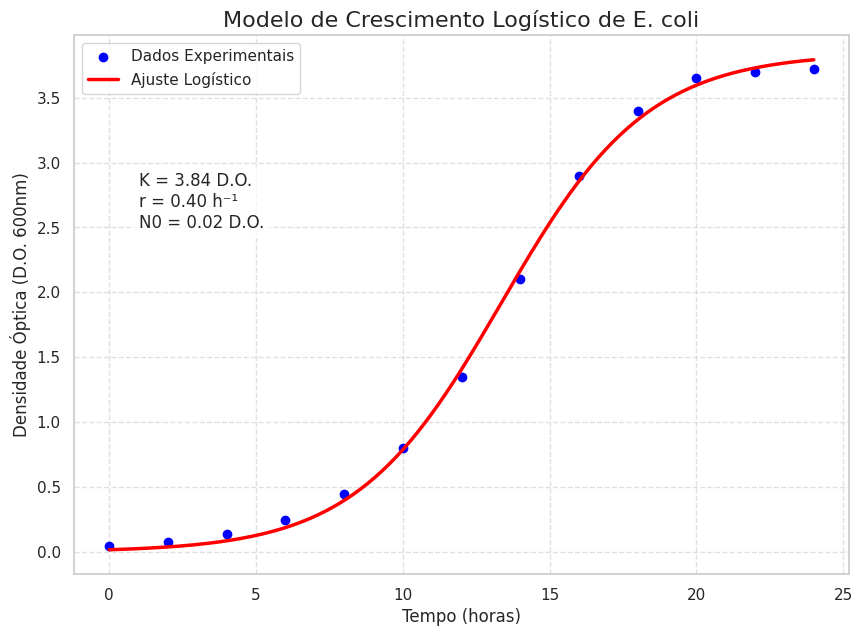

In [ ]:
# --- 1. IMPORTAÇÃO DAS BIBLIOTECAS ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- DADOS FORNECIDOS NO EXERCÍCIO ---
tempo_horas = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
densidade_optica = np.array([
    0.05, 0.08, 0.14, 0.25, 0.45, 0.80, 1.35,
    2.10, 2.90, 3.40, 3.65, 3.70, 3.72
])

# --- 2. DEFINIÇÃO DO MODELO ---
def modelo_logistico(t, K, r, N0):
    """Calcula a densidade populacional usando o modelo de crescimento logístico."""
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# --- 3. AJUSTE DA CURVA ---
# Fornecer uma estimativa inicial (p0) ajuda o algoritmo a convergir.
estimativa_inicial = [5.0, 1.0, densidade_optica[0]]

# Realizar o ajuste
params, _ = curve_fit(modelo_logistico, tempo_horas, densidade_optica, p0=estimativa_inicial)

# Desempacotando os parâmetros encontrados
K_estimado, r_estimado, N0_estimado = params

# --- 4. APRESENTAÇÃO DOS RESULTADOS ---
print("--- Parâmetros da Curva de Crescimento Logístico ---")
print(f"Capacidade de Suporte (K): {K_estimado:.3f} (D.O.)")
print(f"Taxa de Crescimento (r): {r_estimado:.3f} h⁻¹")
print(f"População Inicial (N0): {N0_estimado:.3f} (D.O.)")

# --- 5. CONSTRUÇÃO DO GRÁFICO ---
plt.figure(figsize=(10, 7))

# a) Plotar os dados experimentais
plt.scatter(tempo_horas, densidade_optica, label='Dados Experimentais', color='blue')

# b) Gerar a curva suave com o modelo ajustado
tempo_curva_suave = np.linspace(0, 24, 200)
densidade_prevista_curva = modelo_logistico(tempo_curva_suave, K_estimado, r_estimado, N0_estimado)
plt.plot(tempo_curva_suave, densidade_prevista_curva, label='Ajuste Logístico', color='red', linewidth=2.5)

# Adicionar títulos, rótulos e legenda
plt.title('Modelo de Crescimento Logístico de E. coli', fontsize=16)
plt.xlabel('Tempo (horas)')
plt.ylabel('Densidade Óptica (D.O. 600nm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar a caixa de texto com os resultados
texto_resultados = (
    f'K = {K_estimado:.2f} D.O.\n'
    f'r = {r_estimado:.2f} h⁻¹\n'
    f'N0 = {N0_estimado:.2f} D.O.'
)
plt.text(1, 2.5, texto_resultados, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.7))

# Exibir o gráfico
plt.show()